STOCK MARKET ANALYSIS DASHBOARD

Enter stock tickers separated by commas: aapl,googl,nvda

Enter start date (YYYY-MM-DD): 2022-01-01
Enter end date (YYYY-MM-DD): 2025-12-31

What would you like to see?

1. Price Trends
2. Cumulative Returns
3. Volatility
4. Correlation
5. Show Everything

Enter your choices: 5

SUMMARY TABLE


,Total Return (%),Avg Daily Return (%),Annual Volatility (%),Best Day (%),Worst Day (%)
Ticker,,,,,
AAPL,53.18,0.06,28.54,15.33,-9.25
GOOGL,118.10,0.10,32.67,10.22,-9.51
NVDA,523.83,0.24,53.92,24.37,-16.97



Price Trends


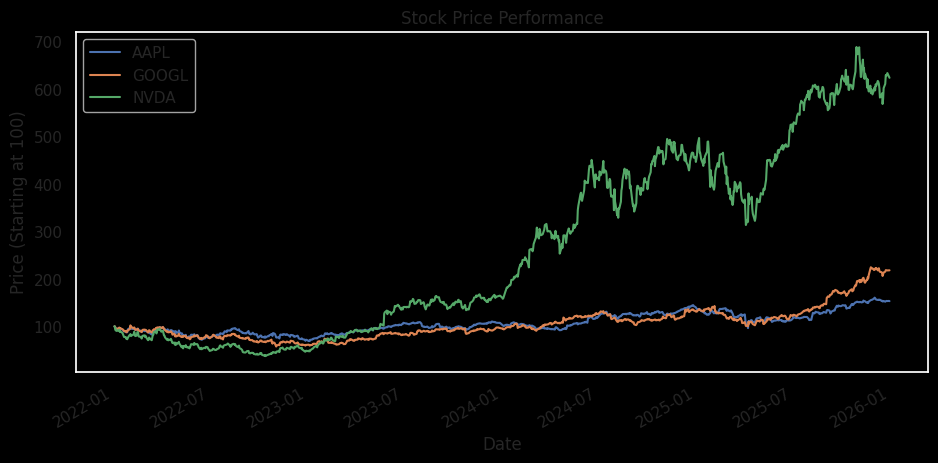


Cumulative Returns


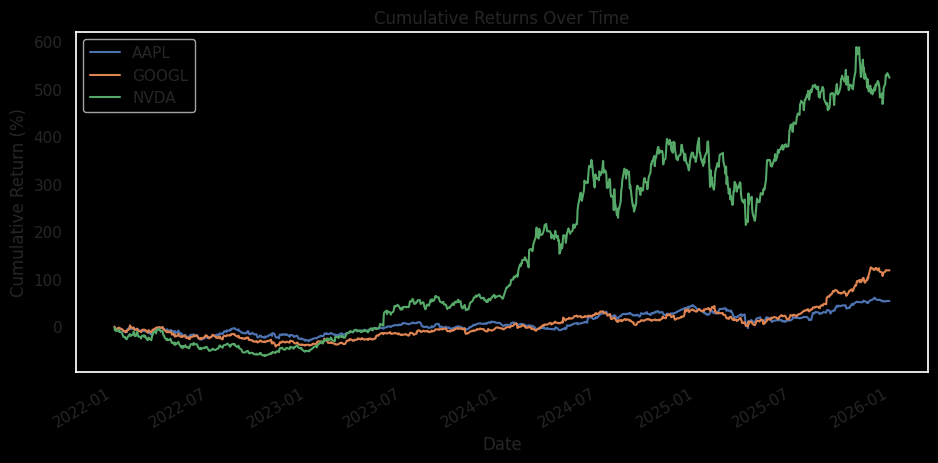


Volatility


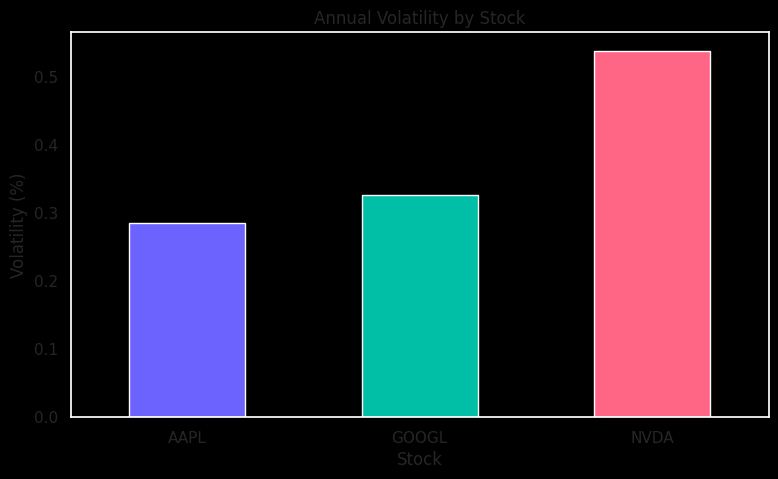


Correlation


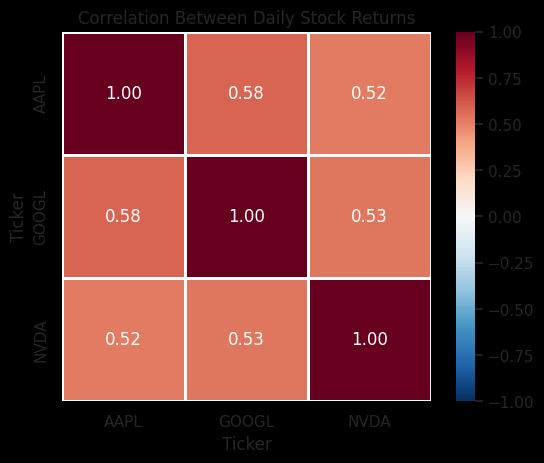

In [6]:
# STOCK MARKET ANALYSIS DASHBOARD

!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="dark")

plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["axes.edgecolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"

TRADING_DAYS = 252


# Clean stock names
def clean_tickers(text):
    tickers = text.split(",")
    return [t.strip().upper() for t in tickers if t.strip()]


# Download stock prices
def fetch_prices(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = data["Close"]
    return prices.dropna()


# Daily Returns
def daily_returns(prices):
    return prices.pct_change().dropna()


# Cumulative Returns
def cumulative_returns(returns):
    return (1 + returns).cumprod() - 1


# Total Returns
def total_returns(prices):
    return prices.iloc[-1] / prices.iloc[0] - 1


# Annual Volatility
def annual_volatility(returns):
    return returns.std() * np.sqrt(TRADING_DAYS)


# Correlation
def correlation_matrix(returns):
    return returns.corr()


# Summary Table
def summary_table(prices, returns):
    table = pd.DataFrame({
        "Total Return (%)": total_returns(prices) * 100,
        "Avg Daily Return (%)": returns.mean() * 100,
        "Annual Volatility (%)": annual_volatility(returns) * 100,
        "Best Day (%)": returns.max() * 100,
        "Worst Day (%)": returns.min() * 100 })

    return table.round(2)


# Price Trend Graph
def plot_prices(prices):
    prices = prices / prices.iloc[0] * 100
    prices.plot(figsize=(11, 5))
    plt.title("Stock Price Performance")
    plt.xlabel("Date")
    plt.ylabel("Price (Starting at 100)")
    plt.legend()
    plt.show()


# Cumulative Returns Graph
def plot_cumulative(cumulative):
    cumulative = cumulative * 100
    cumulative.plot(figsize=(11, 5))
    plt.title("Cumulative Returns Over Time")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return (%)")
    plt.legend()
    plt.show()


# Volatility Graph
def plot_volatility(volatility):
    volatility.plot( kind="bar", figsize=(9, 5), color=["#6C63FF", "#00BFA6", "#FF6584", "#FFB74D"])
    plt.title("Annual Volatility by Stock")
    plt.xlabel("Stock")
    plt.ylabel("Volatility (%)")
    plt.xticks(rotation=0)
    plt.show()


# Correlation Heatmap
def plot_heatmap(correlation):
    sns.heatmap(correlation, annot=True,cmap="RdBu_r", vmin=-1, vmax=1, fmt=".2f", linewidths=1, square=True)
    plt.title("Correlation Between Daily Stock Returns")
    plt.show()


# Main Dashboard
def run_dashboard(tickers, start, end, choices):
    prices = fetch_prices(tickers, start, end)
    returns = daily_returns(prices)
    cumulative = cumulative_returns(returns)
    volatility = annual_volatility(returns)
    correlation = correlation_matrix(returns)

    print("\nSUMMARY TABLE")
    display(summary_table(prices, returns))


    if "1" in choices or "5" in choices:
        print("\nPrice Trends")
        plot_prices(prices)


    if "2" in choices or "5" in choices:
        print("\nCumulative Returns")
        plot_cumulative(cumulative)


    if "3" in choices or "5" in choices:
        print("\nVolatility")
        plot_volatility(volatility)


    if "4" in choices or "5" in choices:

        if len(tickers) >= 2:
            print("\nCorrelation")
            plot_heatmap(correlation)

        else:
            print("\nCorrelation needs at least 2 stocks.")


# USER INPUT
print("STOCK MARKET ANALYSIS DASHBOARD")

user_text = input("\nEnter stock tickers separated by commas: ")
tickers = clean_tickers(user_text)
start = input("\nEnter start date (YYYY-MM-DD): ")
end = input("Enter end date (YYYY-MM-DD): ")

print("""
What would you like to see?

1. Price Trends
2. Cumulative Returns
3. Volatility
4. Correlation
5. Show Everything
""")


choice_input = input("Enter your choices: ")

choices = [
    choice.strip()
    for choice in choice_input.split(",")
]


run_dashboard(tickers, start, end, choices)